In [4]:
from pathlib import Path

import numpy as np
import pandas as pd

FILE = Path("SUMMIT") / "LitDigest_Fase1_Limpo (1).xlsx"

# A planilha da Fase 1 já está limpa e deve ser lida pelos nomes das colunas.
if not FILE.exists():
    raise FileNotFoundError(f"Arquivo não encontrado: {FILE.resolve()}")

excel = pd.ExcelFile(FILE)
print("Abas disponíveis:", excel.sheet_names)

SHEET = "1936_limpo" if "1936_limpo" in excel.sheet_names else excel.sheet_names[0]
base = pd.read_excel(FILE, sheet_name=SHEET)

# Normaliza os nomes sem perder a tabela original em memória.
def normalizar_nome(nome):
    return (
        str(nome)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("-", "_")
    )

base.columns = [normalizar_nome(coluna) for coluna in base.columns]
print(f"Aba usada: {SHEET} | dimensão: {base.shape}")
print("Colunas encontradas:")
print(base.columns.tolist())

# Remove somente linhas sem estado; valores ausentes permanecem ausentes.
if "state" not in base.columns:
    raise KeyError("A planilha precisa conter a coluna 'state'.")

base["state"] = base["state"].astype("string").str.strip()
base = base[base["state"].notna() & (base["state"] != "")].copy()
base = base[~base["state"].str.lower().str.contains("total|unknown", na=False)].reset_index(drop=True)

# Converte números sem transformar ausências em zero.
for coluna in base.columns:
    if coluna != "state":
        valores = base[coluna].astype("string").str.replace(",", "", regex=False)
        valores = valores.replace({"-": pd.NA, "–": pd.NA, "−": pd.NA, "": pd.NA})
        base[coluna] = pd.to_numeric(valores, errors="coerce")

print(f"Estados válidos: {len(base)}")
base.head()

Abas disponíveis: ['Resumo', '1936_limpo', '1932_limpo', 'Dicionario_Colunas', 'Verificacao_Qualidade']
Aba usada: 1936_limpo | dimensão: (48, 52)
Colunas encontradas:
['state', 'electoral_votes', 'landon_total', 'landon_1932_rep', 'landon_1932_dem', 'landon_1932_soc', 'landon_1932_other', 'landon_1932_novote', 'landon_1932_missing', 'roosevelt_total', 'roosevelt_1932_rep', 'roosevelt_1932_dem', 'roosevelt_1932_soc', 'roosevelt_1932_other', 'roosevelt_1932_novote', 'roosevelt_1932_missing', 'lemke_total', 'lemke_1932_rep', 'lemke_1932_dem', 'lemke_1932_soc', 'lemke_1932_other', 'lemke_1932_novote', 'lemke_1932_missing', 'thomas_votes', 'browder_votes', 'colvin_votes', 'aiken_votes', 'others_votes', 'minor_candidates_total', 'grand_total', 'wiki_ev_roosevelt', 'roosevelt_actual_votes', 'roosevelt_actual_pct', 'wiki_ev_landon', 'landon_actual_votes', 'landon_actual_pct', 'wiki_ev_lemke', 'lemke_actual_votes', 'lemke_actual_pct', 'wiki_ev_thomas', 'thomas_actual_votes', 'thomas_actual_pct

,state,electoral_votes,landon_total,landon_1932_rep,landon_1932_dem,landon_1932_soc,landon_1932_other,landon_1932_novote,landon_1932_missing,roosevelt_total,...,wiki_ev_other,other_actual_votes,other_actual_pct,wiki_ev_margin,margin_actual_votes,margin_actual_pct,total_actual_votes,state_abbr,soma_candidatos,diferenca_total
0,Alabama,11,3060,1218,1298,3,3,412,126,10082,...,0,1397,0.51,0,202838,73.56,275244,<NA>,13273,0
1,Arizona,3,2337,1431,647,18,0,129,112,1975,...,0,384,0.31,0,53289,42.92,124163,<NA>,4476,0
2,Arkansas,9,2724,1338,953,7,9,274,143,7608,...,0,169,0.09,0,114726,63.94,179423,<NA>,10540,0
3,California,22,89516,65360,16200,315,53,3519,4069,77245,...,0,24284,0.92,0,930405,35.26,2638882,<NA>,173935,0
4,Colorado,6,15949,11872,2714,131,12,637,583,10025,...,0,841,0.17,0,113754,23.28,488684,<NA>,26786,0


## Fase 3 — Correlação e discrepância

Nesta etapa, os totais da amostra da Literary Digest serão comparados aos votos oficiais de 1936. Os totais da Digest são um proxy da intenção, não uma pesquisa direta de intenção de voto.

In [6]:
CANDIDATOS = {
    "Landon": {"digest": "landon_total", "actual": "landon_actual_votes"},
    "Roosevelt": {"digest": "roosevelt_total", "actual": "roosevelt_actual_votes"},
    "Lemke": {"digest": "lemke_total", "actual": "lemke_actual_votes"},
    "Outros": {"digest": "minor_candidates_total", "actual": "other_actual_votes"},
}

colunas_necessarias = {
    "total_actual_votes",
    *[coluna for candidato in CANDIDATOS.values() for coluna in candidato.values()],
}
colunas_ausentes = sorted(colunas_necessarias - set(base.columns))
if colunas_ausentes:
    raise KeyError(f"Colunas necessárias ausentes: {colunas_ausentes}")

# Valida o total oficial informado pela Fase 1.
base["soma_actual_calculada"] = base[[dados["actual"] for dados in CANDIDATOS.values()]].sum(axis=1)
base["diferenca_actual_calculada"] = base["total_actual_votes"] - base["soma_actual_calculada"]
print("Maior diferença entre total_actual_votes e a soma dos candidatos:", base["diferenca_actual_calculada"].abs().max())
print("Diferenças diferentes de zero:", (base["diferenca_actual_calculada"] != 0).sum())

registros = []
colunas_digest = [dados["digest"] for dados in CANDIDATOS.values()]
for candidato, colunas in CANDIDATOS.items():
    tabela = base[["state", "electoral_votes", colunas["digest"], colunas["actual"], "total_actual_votes"]].copy()
    tabela = tabela.rename(columns={colunas["digest"]: "digest_votes", colunas["actual"]: "actual_votes"})
    tabela["candidate"] = candidato
    tabela["digest_total_state"] = base[colunas_digest].sum(axis=1).to_numpy()
    tabela["digest_share"] = tabela["digest_votes"] / tabela["digest_total_state"]
    tabela["actual_share"] = tabela["actual_votes"] / tabela["total_actual_votes"]
    tabela["difference_pp"] = (tabela["actual_share"] - tabela["digest_share"]) * 100
    tabela["absolute_error_pp"] = tabela["difference_pp"].abs()
    tabela["relative_error"] = np.where(
        tabela["actual_votes"] != 0,
        (tabela["digest_votes"] - tabela["actual_votes"]) / tabela["actual_votes"],
        np.nan,
    )
    registros.append(tabela)

analise = pd.concat(registros, ignore_index=True)
analise.head()

Maior diferença entre total_actual_votes e a soma dos candidatos: 86897
Diferenças diferentes de zero: 39


,state,electoral_votes,digest_votes,actual_votes,total_actual_votes,candidate,digest_total_state,digest_share,actual_share,difference_pp,absolute_error_pp,relative_error
0,Alabama,11,3060,35358,275244,Landon,13273,0.230543,0.128461,-10.208264,10.208264,-0.913457
1,Arizona,3,2337,33433,124163,Landon,4476,0.522118,0.269267,-25.285095,25.285095,-0.930099
2,Arkansas,9,2724,32039,179423,Landon,10540,0.258444,0.178567,-7.987717,7.987717,-0.914979
3,California,22,89516,836431,2638882,Landon,173935,0.514652,0.316964,-19.768787,19.768787,-0.892979
4,Colorado,6,15949,181267,488684,Landon,26786,0.595423,0.370929,-22.449412,22.449412,-0.912014


In [7]:
## Auditoria dos totais oficiais

colunas_auditoria = [
    "state",
    "roosevelt_actual_votes",
    "landon_actual_votes",
    "lemke_actual_votes",
    "other_actual_votes",
    "total_actual_votes",
    "soma_actual_calculada",
    "diferenca_actual_calculada",
]
print("Estados com divergência entre o total e os candidatos:")
print(
    base.loc[base["diferenca_actual_calculada"] != 0, colunas_auditoria]
    .sort_values("diferenca_actual_calculada", key=lambda serie: serie.abs(), ascending=False)
    .head(10)
)

if "diferenca_total" in base.columns:
    print("\nResumo da verificação já fornecida pela Fase 1:")
    print(base[["diferenca_total"]].describe())

Estados com divergência entre o total e os candidatos:
            state  roosevelt_actual_votes  landon_actual_votes  \
29       New York                 3293222              2180670   
35   Pennsylvania                 2353987              1690200   
3      California                 1766836               836431   
46      Wisconsin                  802984               380828   
19       Michigan                 1016794               699733   
10       Illinois                 2282999              1570393   
5     Connecticut                  382129               278685   
18  Massachusetts                  942716               768613   
27     New Jersey                 1083850               720322   
11        Indiana                  934974               691570   

    lemke_actual_votes  other_actual_votes  total_actual_votes  \
29                   0               35609             5596398   
35               67468               12172             4138426   
3                   

## Correlação e métricas do viés

As correlações serão calculadas tanto para contagens quanto para participações estaduais. A segunda comparação reduz o efeito mecânico do tamanho de cada estado.

In [8]:
correlacoes = []
metricas = []

for candidato in CANDIDATOS:
    dados = analise[analise["candidate"] == candidato].dropna(subset=["digest_votes", "actual_votes", "digest_share", "actual_share"])
    correlacoes.append(
        {
            "candidate": candidato,
            "n_states": len(dados),
            "pearson_counts": dados["digest_votes"].corr(dados["actual_votes"], method="pearson"),
            "spearman_counts": dados["digest_votes"].corr(dados["actual_votes"], method="spearman"),
            "pearson_shares": dados["digest_share"].corr(dados["actual_share"], method="pearson"),
            "spearman_shares": dados["digest_share"].corr(dados["actual_share"], method="spearman"),
        }
    )
    metricas.append(
        {
            "candidate": candidato,
            "bias_mean_pp": dados["difference_pp"].mean(),
            "mae_pp": dados["absolute_error_pp"].mean(),
            "rmse_pp": np.sqrt((dados["difference_pp"] ** 2).mean()),
            "largest_error_state": dados.loc[dados["absolute_error_pp"].idxmax(), "state"],
        }
    )

correlacoes = pd.DataFrame(correlacoes)
metricas = pd.DataFrame(metricas)
print("Correlações:")
display(correlacoes)
print("Métricas de discrepância em pontos percentuais:")
display(metricas)

Correlações:


,candidate,n_states,pearson_counts,spearman_counts,pearson_shares,spearman_shares
0,Landon,48,0.978975,0.966240,0.892383,0.855623
1,Roosevelt,48,0.973585,0.955493,0.910979,0.883956
2,Lemke,48,0.584405,0.640684,0.818012,0.663439
3,Outros,48,0.936538,0.807009,0.492235,0.390709


Métricas de discrepância em pontos percentuais:


,candidate,bias_mean_pp,mae_pp,rmse_pp,largest_error_state
0,Landon,-17.395449,17.395449,18.753780,Massachusetts
1,Roosevelt,18.724083,18.724083,19.987495,Massachusetts
2,Lemke,-0.910517,1.253310,1.750569,Louisiana
3,Outros,-0.646980,0.648351,0.715652,New York


## Fase 4 — Modelo de correção

O modelo usa a participação estadual da amostra Digest para prever a participação oficial. `total_actual_votes` não entra como preditor, pois participa da definição do alvo e causaria vazamento de informação.

In [9]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, cross_val_predict

modelo_resultados = []
modelos = {}
cv = KFold(n_splits=5, shuffle=True, random_state=42)

for candidato in CANDIDATOS:
    dados = analise[analise["candidate"] == candidato].dropna(subset=["digest_share", "actual_share"]).copy()
    X = dados[["digest_share"]]
    y = dados["actual_share"]

    modelo = LinearRegression()
    previsao_cv = cross_val_predict(modelo, X, y, cv=cv)
    modelo.fit(X, y)
    previsao_bruta = dados["digest_share"].to_numpy()

    modelos[candidato] = modelo
    modelo_resultados.append(
        {
            "candidate": candidato,
            "intercept": modelo.intercept_,
            "slope": modelo.coef_[0],
            "mae_digest_bruta_pp": mean_absolute_error(y, previsao_bruta) * 100,
            "mae_regressao_cv_pp": mean_absolute_error(y, previsao_cv) * 100,
            "rmse_regressao_cv_pp": np.sqrt(mean_squared_error(y, previsao_cv)) * 100,
            "r2_regressao_cv": r2_score(y, previsao_cv),
        }
    )

modelo_resultados = pd.DataFrame(modelo_resultados)
print("Comparação entre a amostra Digest e a regressão:")
display(modelo_resultados)

Comparação entre a amostra Digest e a regressão:


,candidate,intercept,slope,mae_digest_bruta_pp,mae_regressao_cv_pp,rmse_regressao_cv_pp,r2_regressao_cv
0,Landon,-0.022459,0.698823,17.395449,4.620320,5.523163,0.781587
1,Roosevelt,0.321084,0.709113,18.724083,4.250829,5.370523,0.817325
2,Lemke,-0.005580,0.875751,1.253310,1.065854,1.601289,0.605049
3,Outros,-0.000267,0.269753,0.648351,0.128413,0.176330,0.158246


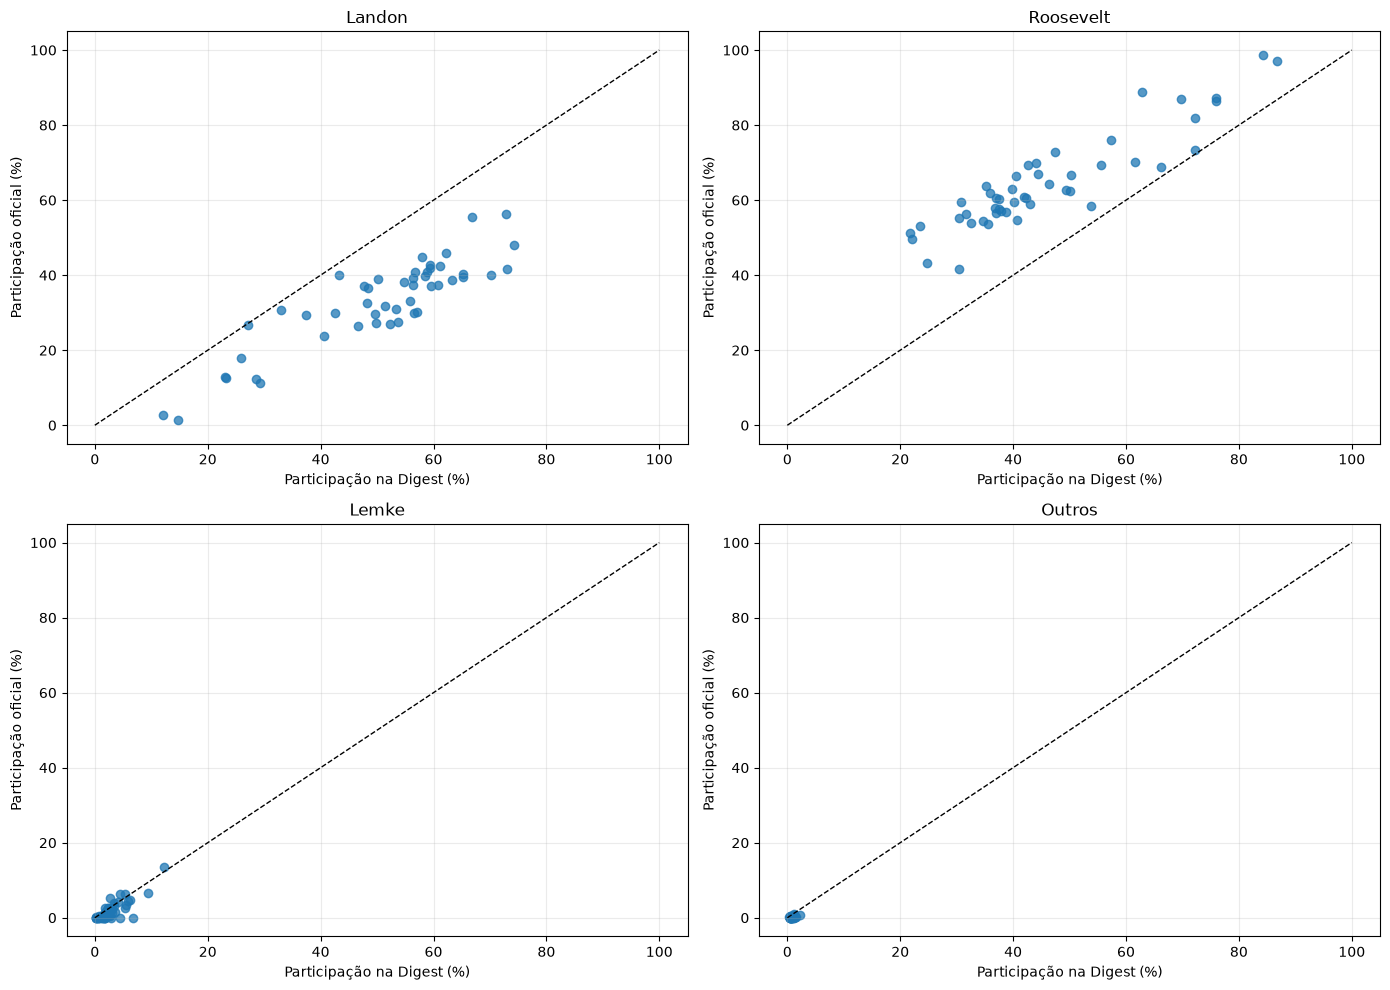

,state,candidate,digest_share,actual_share,difference_pp,absolute_error_pp
18,Massachusetts,Landon,0.729782,0.417643,-31.213818,31.213818
36,Rhode Island,Landon,0.701917,0.401799,-30.011762,30.011762
66,Massachusetts,Roosevelt,0.216684,0.512246,29.556249,29.556249
84,Rhode Island,Roosevelt,0.235457,0.531008,29.55511,29.55511
75,New Jersey,Roosevelt,0.30751,0.595379,28.786906,28.786906
94,Wisconsin,Roosevelt,0.351161,0.638018,28.685715,28.685715
74,New Hampshire,Roosevelt,0.22069,0.497263,27.657269,27.657269
46,Wisconsin,Landon,0.571091,0.30259,-26.850035,26.850035
44,Washington,Landon,0.565239,0.298831,-26.640832,26.640832
71,Montana,Roosevelt,0.426485,0.692762,26.627752,26.627752


In [10]:
## Visualização e estados mais discrepantes

import matplotlib.pyplot as plt

fig, eixos = plt.subplots(2, 2, figsize=(14, 10))
for eixo, candidato in zip(eixos.flat, CANDIDATOS):
    dados = analise[analise["candidate"] == candidato]
    eixo.scatter(dados["digest_share"] * 100, dados["actual_share"] * 100, alpha=0.75)
    eixo.plot([0, 100], [0, 100], linestyle="--", color="black", linewidth=1)
    eixo.set_title(candidato)
    eixo.set_xlabel("Participação na Digest (%)")
    eixo.set_ylabel("Participação oficial (%)")
    eixo.grid(alpha=0.25)

plt.tight_layout()
plt.show()

maiores_discrepancias = (
    analise[["state", "candidate", "digest_share", "actual_share", "difference_pp", "absolute_error_pp"]]
    .sort_values("absolute_error_pp", ascending=False)
    .head(15)
)
maiores_discrepancias